
### Project Outline
1. Load Dataset & Basic Data Analysis
2. Missing Value Check & Correlation Analysis
3. Target Variable Engineering (Binary Classification)
4. Train-Test Split
5. Logistic Regression (Without Scaling)
6. Logistic Regression (With Scaling) — Before vs After Comparison
7. Model Comparison: Logistic Regression vs KNN vs Decision Tree
8. Hyperparameter Tuning with GridSearchCV
9. Feature Importance Analysis


## 📦 Step 0 — Install & Import Required Libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 📂 Step 1 — Load Dataset & Basic Data Analysis

In [39]:
df = pd.read_csv(r'C:\Users\tanya\Downloads\winequality.csv')

print('Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset loaded successfully!
Shape: 1599 rows × 12 columns


In [40]:
print(' head() — First 5 Rows:')
df.head()

 head() — First 5 Rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [41]:
print('info() — Dataset Structure:')
df.info()

info() — Dataset Structure:
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [42]:
print('describe() — Statistical Summary:')
df.describe().round(2)

describe() — Statistical Summary:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


Quality Score Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


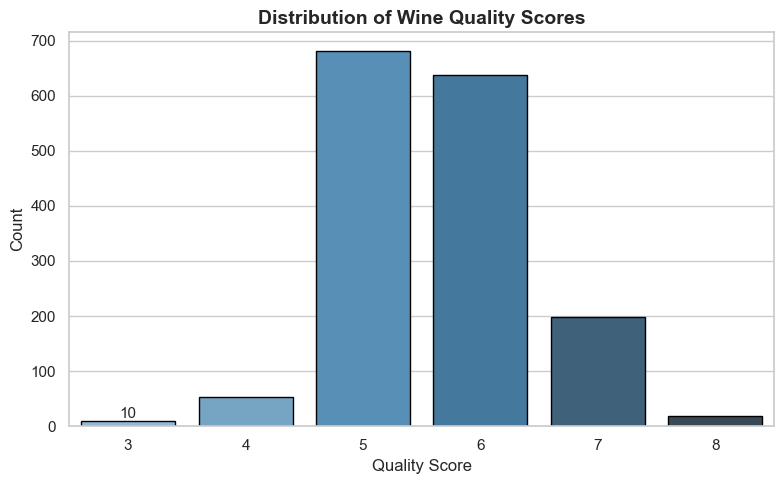

In [43]:
print('Quality Score Distribution:')
print(df['quality'].value_counts().sort_index())

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='quality', data=df, palette='Blues_d', edgecolor='black')
ax.bar_label(ax.containers[0], fontsize=11)
plt.title('Distribution of Wine Quality Scores', fontsize=14, fontweight='bold')
plt.xlabel('Quality Score', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

---
## 🔍 Step 2 — Missing Values & Correlation Analysis

In [44]:
missing = df.isnull().sum()
print('Missing Values Per Column:')
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

Missing Values Per Column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing values: 0


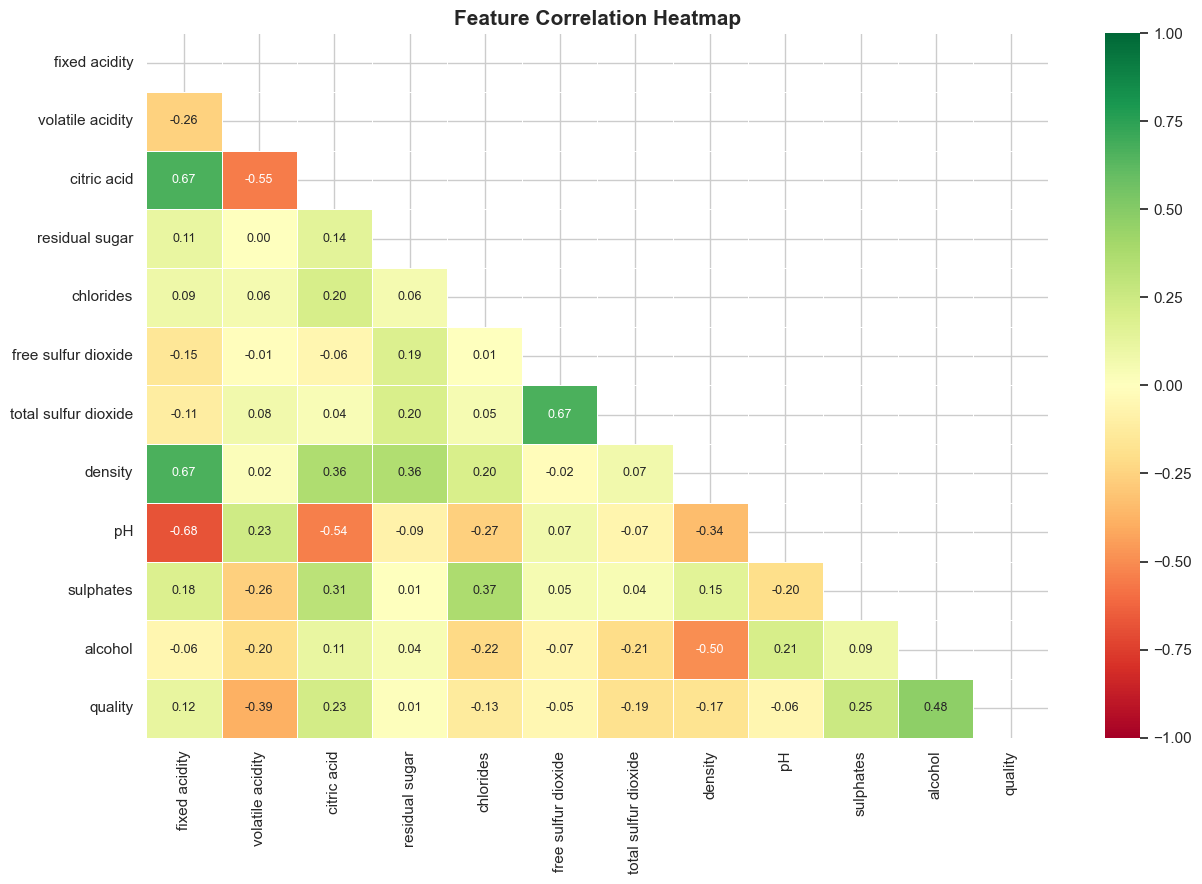

In [45]:
plt.figure(figsize=(13, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) 
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', linewidths=0.5,
    vmin=-1, vmax=1, center=0,
    annot_kws={'size': 9}
)
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Feature Correlations with Quality (sorted):
alcohol                 0.476
sulphates               0.251
citric acid             0.226
fixed acidity           0.124
residual sugar          0.014
free sulfur dioxide    -0.051
pH                     -0.058
chlorides              -0.129
density                -0.175
total sulfur dioxide   -0.185
volatile acidity       -0.391
Name: quality, dtype: float64


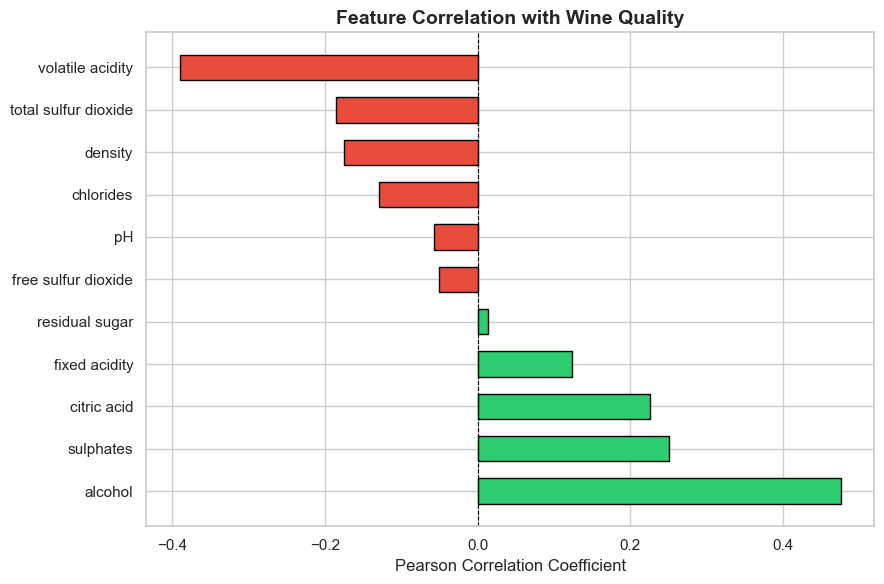


🔑 Key Insight:
  Strongest POSITIVE correlation: alcohol (0.476)
  Strongest NEGATIVE correlation: volatile acidity (-0.391)


In [46]:
quality_corr = df.corr()['quality'].drop('quality').sort_values(ascending=False)
print('Feature Correlations with Quality (sorted):')
print(quality_corr.round(3))

plt.figure(figsize=(9, 6))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in quality_corr.values]
bars = plt.barh(quality_corr.index, quality_corr.values, color=colors, edgecolor='black', height=0.6)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Correlation with Wine Quality', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.tight_layout()
plt.show()

print('\n🔑 Key Insight:')
print(f'  Strongest POSITIVE correlation: {quality_corr.idxmax()} ({quality_corr.max():.3f})')
print(f'  Strongest NEGATIVE correlation: {quality_corr.idxmin()} ({quality_corr.min():.3f})')

---
## 🎯 Step 3 — Binary Target Variable Engineering

Binary Target Created: quality_label
  GOOD wines (quality ≥ 7) → 1 : 217 samples
  BAD  wines (quality < 7) → 0 : 1382 samples


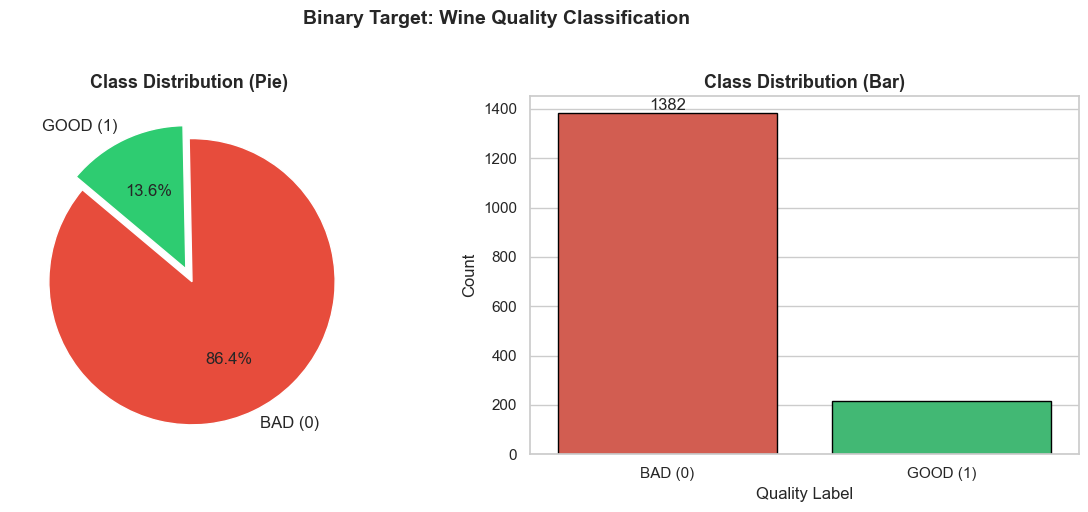


Class imbalance ratio — BAD:GOOD = 1382:217


In [47]:
df['quality_label'] = (df['quality'] >= 7).astype(int)

label_map = {1: 'GOOD', 0: 'BAD'}
label_counts = df['quality_label'].value_counts()

print('Binary Target Created: quality_label')
print(f'  GOOD wines (quality ≥ 7) → 1 : {label_counts[1]} samples')
print(f'  BAD  wines (quality < 7) → 0 : {label_counts[0]} samples')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    label_counts, labels=['BAD (0)', 'GOOD (1)'],
    autopct='%1.1f%%', startangle=140,
    colors=['#e74c3c', '#2ecc71'], explode=(0.05, 0.05),
    textprops={'fontsize': 12}
)
axes[0].set_title('Class Distribution (Pie)', fontsize=13, fontweight='bold')

ax2 = sns.countplot(x='quality_label', data=df, palette=['#e74c3c', '#2ecc71'],
                    edgecolor='black', ax=axes[1])
ax2.bar_label(ax2.containers[0], fontsize=12)
axes[1].set_xticklabels(['BAD (0)', 'GOOD (1)'], fontsize=11)
axes[1].set_title('Class Distribution (Bar)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Quality Label')
axes[1].set_ylabel('Count')

plt.suptitle('Binary Target: Wine Quality Classification', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nClass imbalance ratio — BAD:GOOD = {label_counts[0]}:{label_counts[1]}')

---
## ✂️ Step 4 — Feature/Target Separation & Train-Test Split

In [48]:
X = df.drop(columns=['quality', 'quality_label'])
y = df['quality_label']

print('Features (X):', X.shape)
print('Target  (y):', y.shape)
print('\nFeature columns:', list(X.columns))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain set: {X_train.shape[0]} samples')
print(f'Test  set: {X_test.shape[0]} samples')
print(f'\nClass distribution in Train: {dict(y_train.value_counts())}')
print(f'Class distribution in Test:  {dict(y_test.value_counts())}')

Features (X): (1599, 11)
Target  (y): (1599,)

Feature columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Train set: 1279 samples
Test  set: 320 samples

Class distribution in Train: {0: np.int64(1105), 1: np.int64(174)}
Class distribution in Test:  {0: np.int64(277), 1: np.int64(43)}


---
## 🤖 Step 5 — Logistic Regression WITHOUT Scaling


  Logistic Regression (No Scaling)
  Accuracy  : 0.8938
  Precision : 0.7368
  Recall    : 0.3256
  F1-Score  : 0.4516

  Classification Report:
              precision    recall  f1-score   support

         BAD       0.90      0.98      0.94       277
        GOOD       0.74      0.33      0.45        43

    accuracy                           0.89       320
   macro avg       0.82      0.65      0.70       320
weighted avg       0.88      0.89      0.88       320



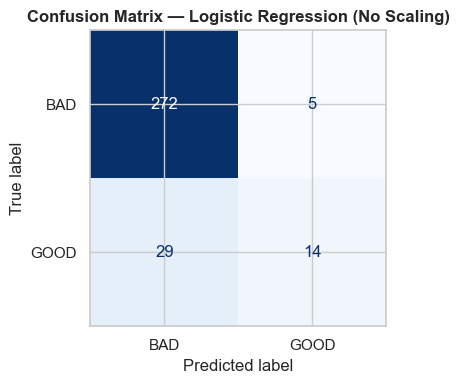

In [49]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, title='Model'):
    """Train model and return evaluation metrics + confusion matrix."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    cm   = confusion_matrix(y_te, y_pred)

    print(f'\n{'='*55}')
    print(f'  {title}')
    print(f'{'='*55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(y_te, y_pred, target_names=['BAD', 'GOOD']))

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['BAD', 'GOOD'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {title}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


lr_no_scale = LogisticRegression(random_state=42, max_iter=1000)
metrics_lr_raw = evaluate_model(
    lr_no_scale, X_train, X_test, y_train, y_test,
    title='Logistic Regression (No Scaling)'
)

---
## ⚖️ Step 6 — Apply StandardScaler & Compare Before vs After Scaling

✅ StandardScaler applied.
  Mean of scaled training features (should be ≈0): [ 0.  0.  0.  0.  0. -0. -0. -0. -0. -0.  0.]
  Std  of scaled training features (should be ≈1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

  Logistic Regression (With Scaling)
  Accuracy  : 0.8938
  Precision : 0.6957
  Recall    : 0.3721
  F1-Score  : 0.4848

  Classification Report:
              precision    recall  f1-score   support

         BAD       0.91      0.97      0.94       277
        GOOD       0.70      0.37      0.48        43

    accuracy                           0.89       320
   macro avg       0.80      0.67      0.71       320
weighted avg       0.88      0.89      0.88       320



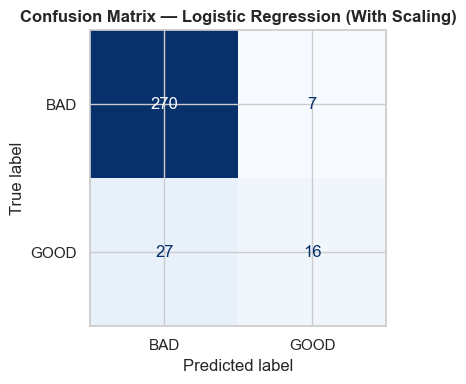

In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled  = scaler.transform(X_test)         

print('✅ StandardScaler applied.')
print(f'  Mean of scaled training features (should be ≈0): {X_train_scaled.mean(axis=0).round(3)}')
print(f'  Std  of scaled training features (should be ≈1): {X_train_scaled.std(axis=0).round(3)}')

lr_scaled = LogisticRegression(random_state=42, max_iter=1000)
metrics_lr_scaled = evaluate_model(
    lr_scaled, X_train_scaled, X_test_scaled, y_train, y_test,
    title='Logistic Regression (With Scaling)'
)


Before vs After Scaling — Logistic Regression:
           Without Scaling  With Scaling
Metric                                  
Accuracy            0.8938        0.8938
Precision           0.7368        0.6957
Recall              0.3256        0.3721
F1-Score            0.4516        0.4848


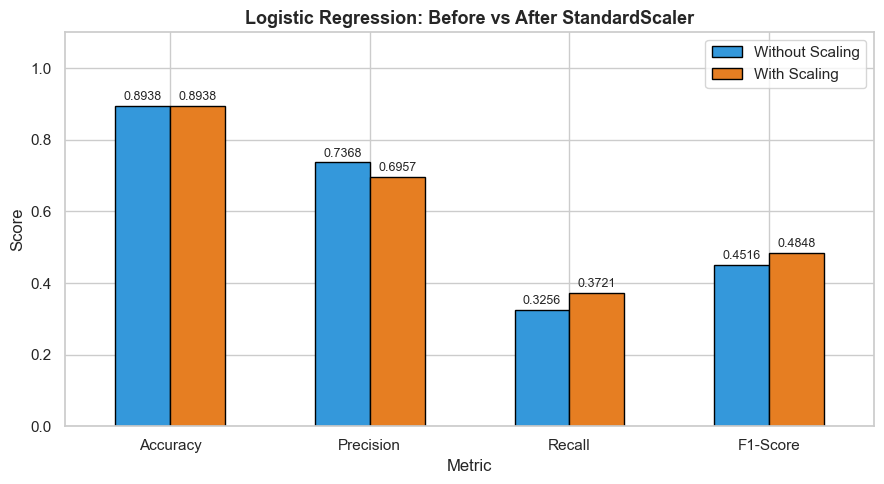

In [51]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Without Scaling': [metrics_lr_raw['accuracy'],  metrics_lr_raw['precision'],
                        metrics_lr_raw['recall'],     metrics_lr_raw['f1']],
    'With Scaling':    [metrics_lr_scaled['accuracy'], metrics_lr_scaled['precision'],
                        metrics_lr_scaled['recall'],   metrics_lr_scaled['f1']]
})
comparison_df = comparison_df.set_index('Metric')

print('\nBefore vs After Scaling — Logistic Regression:')
print(comparison_df.round(4).to_string())

ax = comparison_df.plot(kind='bar', figsize=(9, 5), rot=0, edgecolor='black',
                        color=['#3498db', '#e67e22'], width=0.55)
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=9, padding=2)
plt.title('Logistic Regression: Before vs After StandardScaler', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 🏆 Step 7 — Model Comparison: Logistic Regression vs KNN vs Decision Tree

In [52]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':        DecisionTreeClassifier(random_state=42)
}

results = {}
print('\nTraining and evaluating all models on SCALED data...\n')

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred, zero_division=0)
    }

results_df = pd.DataFrame(results).T
print('Model Comparison Table:')
print(results_df.round(4).to_string())

best_model_name = results_df['F1-Score'].idxmax()
print(f'\nBest Model (by F1-Score): {best_model_name} — F1 = {results_df.loc[best_model_name, "F1-Score"]:.4f}')


Training and evaluating all models on SCALED data...

Model Comparison Table:
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8938     0.6957  0.3721    0.4848
KNN (k=5)              0.8938     0.6667  0.4186    0.5143
Decision Tree          0.9062     0.6383  0.6977    0.6667

Best Model (by F1-Score): Decision Tree — F1 = 0.6667


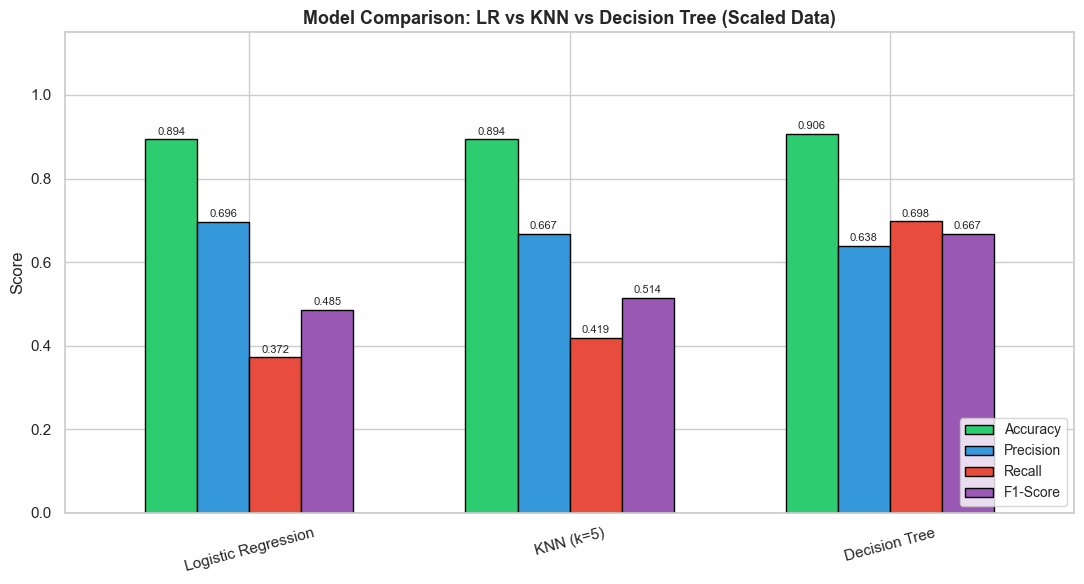


 5-Fold Cross-Validation Accuracy:
  Logistic Regression      : Mean F1 = 0.4063  (±0.0722)
  KNN (k=5)                : Mean F1 = 0.4154  (±0.0731)
  Decision Tree            : Mean F1 = 0.5127  (±0.0488)


In [53]:
ax = results_df.plot(kind='bar', figsize=(11, 6), rot=15, edgecolor='black', width=0.65,
                     color=['#2ecc71', '#3498db', '#e74c3c', '#9b59b6'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.title('Model Comparison: LR vs KNN vs Decision Tree (Scaled Data)', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.15)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

print('\n 5-Fold Cross-Validation Accuracy:')
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
    print(f'  {name:25s}: Mean F1 = {cv_scores.mean():.4f}  (±{cv_scores.std():.4f})')

---
## 🔧 Step 8 — Hyperparameter Tuning with GridSearchCV

In [54]:
print('Running GridSearchCV on Decision Tree...')

param_grid_dt = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'criterion':         ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_dt.fit(X_train_scaled, y_train)

print(f'\n Best Parameters Found:')
for param, value in grid_dt.best_params_.items():
    print(f'   {param}: {value}')
print(f'\n Best CV F1-Score: {grid_dt.best_score_:.4f}')

Running GridSearchCV on Decision Tree...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

 Best Parameters Found:
   criterion: entropy
   max_depth: None
   min_samples_leaf: 1
   min_samples_split: 2

 Best CV F1-Score: 0.5274



  Decision Tree (GridSearchCV Tuned)
  Accuracy  : 0.9250
  Precision : 0.7317
  Recall    : 0.6977
  F1-Score  : 0.7143

  Classification Report:
              precision    recall  f1-score   support

         BAD       0.95      0.96      0.96       277
        GOOD       0.73      0.70      0.71        43

    accuracy                           0.93       320
   macro avg       0.84      0.83      0.84       320
weighted avg       0.92      0.93      0.92       320



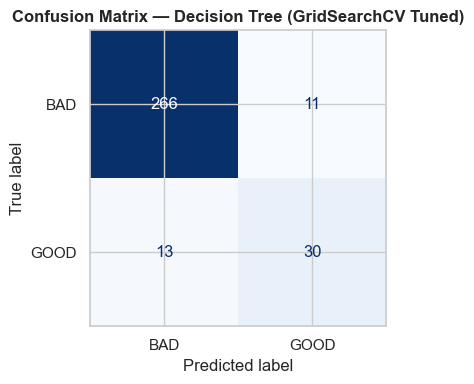

In [55]:
best_dt = grid_dt.best_estimator_
metrics_tuned = evaluate_model(
    best_dt, X_train_scaled, X_test_scaled, y_train, y_test,
    title='Decision Tree (GridSearchCV Tuned)'
)


Decision Tree — Before vs After Hyperparameter Tuning:
           Before Tuning  After Tuning
Metric                                
Accuracy          0.9062        0.9250
Precision         0.6383        0.7317
Recall            0.6977        0.6977
F1-Score          0.6667        0.7143


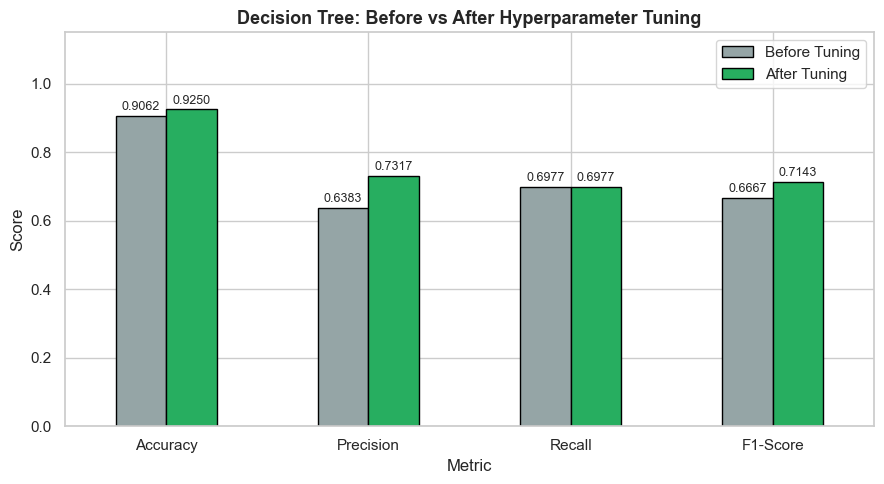

In [56]:
base_dt_metrics = results['Decision Tree']

tuning_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Before Tuning': [base_dt_metrics['Accuracy'], base_dt_metrics['Precision'],
                      base_dt_metrics['Recall'],   base_dt_metrics['F1-Score']],
    'After Tuning':  [metrics_tuned['accuracy'],  metrics_tuned['precision'],
                      metrics_tuned['recall'],     metrics_tuned['f1']]
}).set_index('Metric')

print('\nDecision Tree — Before vs After Hyperparameter Tuning:')
print(tuning_df.round(4).to_string())

ax = tuning_df.plot(kind='bar', figsize=(9, 5), rot=0, edgecolor='black',
                    color=['#95a5a6', '#27ae60'], width=0.5)
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=9, padding=2)
plt.title('Decision Tree: Before vs After Hyperparameter Tuning', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.15)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 📌 Step 9 — Feature Importance Analysis

Decision Tree — Feature Importances (Gini):
             Feature  Importance
             alcohol      0.2859
           sulphates      0.1017
    volatile acidity      0.0973
                  pH      0.0866
total sulfur dioxide      0.0789
           chlorides      0.0717
      residual sugar      0.0714
         citric acid      0.0614
 free sulfur dioxide      0.0581
             density      0.0533
       fixed acidity      0.0338


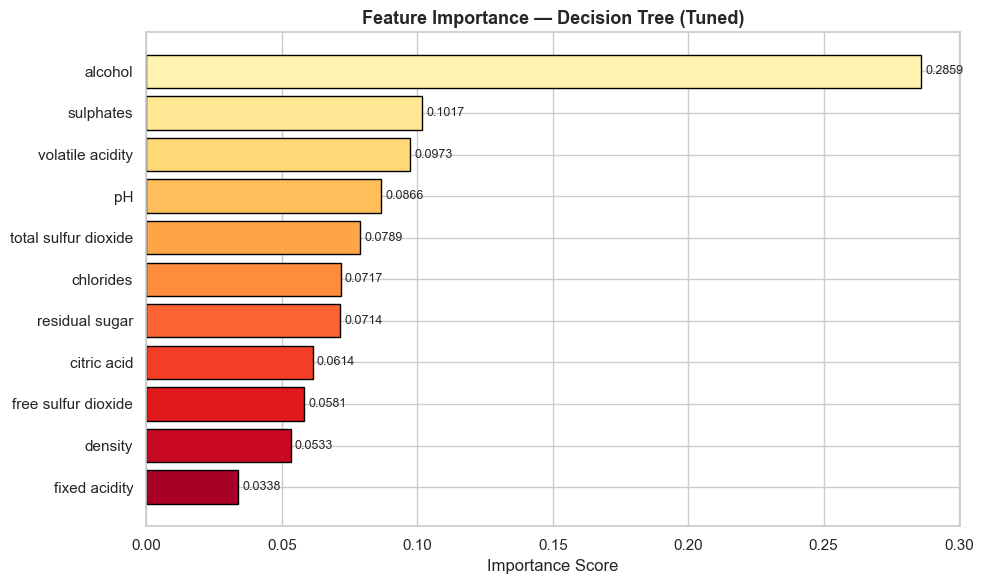

In [57]:
feature_names = X.columns.tolist()
importances_dt = best_dt.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature':   feature_names,
    'Importance': importances_dt
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('Decision Tree — Feature Importances (Gini):')
print(feat_imp_df.round(4).to_string(index=False))

plt.figure(figsize=(10, 6))
colors = sns.color_palette('YlOrRd', len(feat_imp_df))[::-1]
bars = plt.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1],
                color=colors, edgecolor='black')
plt.bar_label(bars, fmt='%.4f', fontsize=9, padding=3)
plt.title('Feature Importance — Decision Tree (Tuned)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


 Logistic Regression — Feature Coefficients (Scaled):
             Feature  Coefficient
             alcohol       0.8944
           sulphates       0.6111
 free sulfur dioxide       0.2773
      residual sugar       0.2387
       fixed acidity       0.2177
         citric acid       0.1054
                  pH      -0.1517
             density      -0.2755
           chlorides      -0.3678
    volatile acidity      -0.4257
total sulfur dioxide      -0.8174


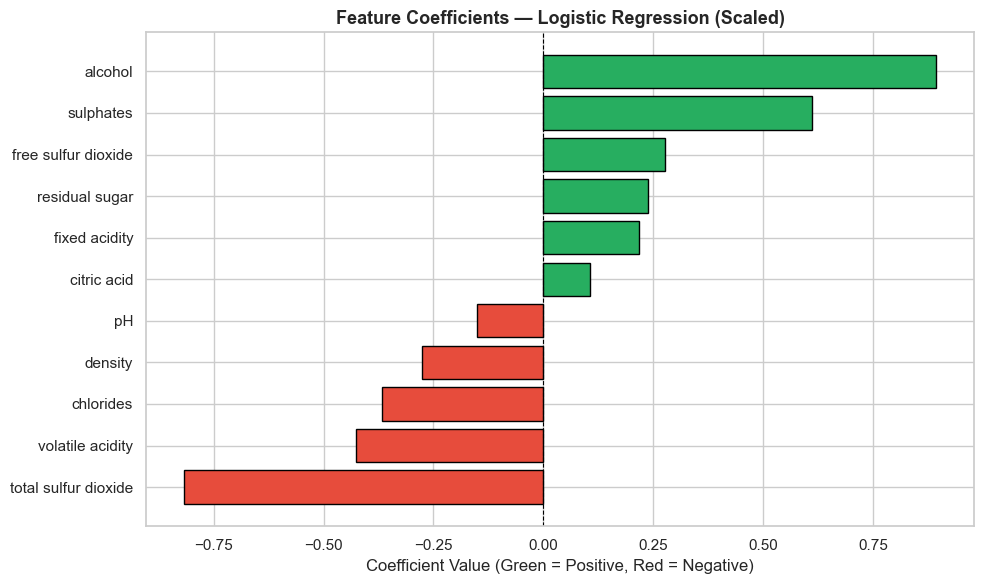

In [58]:
lr_coefs = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': lr_scaled.coef_[0]
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print('\n Logistic Regression — Feature Coefficients (Scaled):')
print(lr_coefs.round(4).to_string(index=False))

colors = ['#27ae60' if c > 0 else '#e74c3c' for c in lr_coefs['Coefficient']]
plt.figure(figsize=(10, 6))
bars = plt.barh(lr_coefs['Feature'][::-1], lr_coefs['Coefficient'][::-1],
                color=colors[::-1], edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Coefficients — Logistic Regression (Scaled)', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value (Green = Positive, Red = Negative)')
plt.tight_layout()
plt.show()

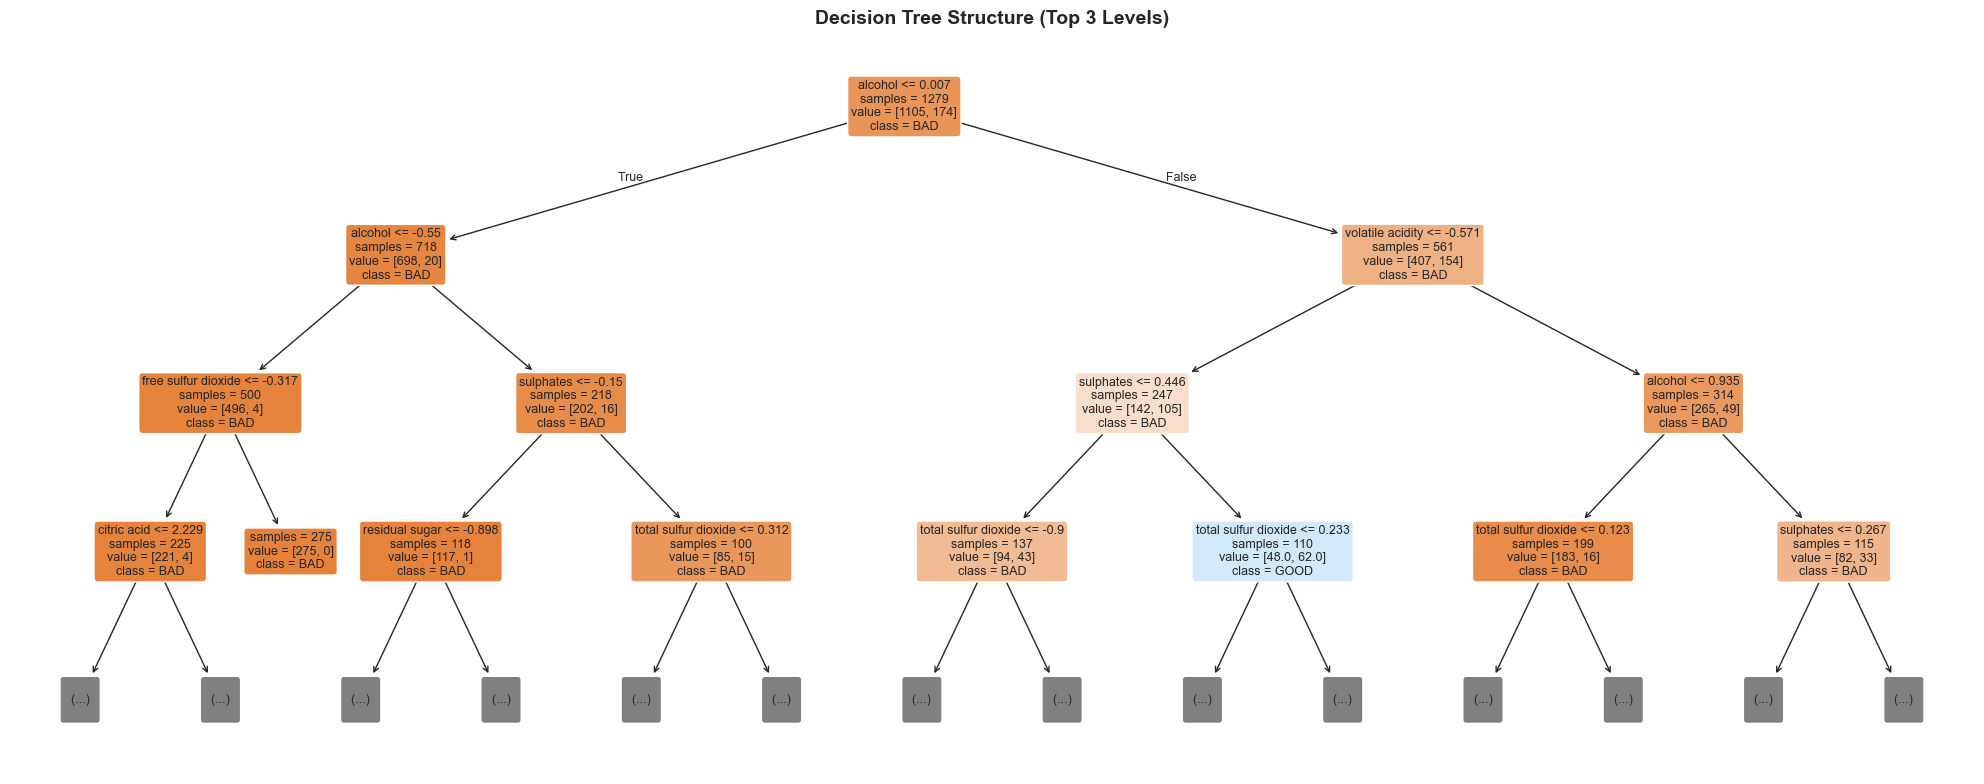

In [59]:
plt.figure(figsize=(20, 8))
plot_tree(
    best_dt,
    feature_names=feature_names,
    class_names=['BAD', 'GOOD'],
    filled=True,
    max_depth=3,          
    fontsize=9,
    rounded=True,
    impurity=False
)
plt.title('Decision Tree Structure (Top 3 Levels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📝 Step 10 — Final Summary & Conclusions

In [60]:
summary_data = {
    'LR (No Scale)': metrics_lr_raw,
    'LR (Scaled)':   metrics_lr_scaled,
    **{k: {'accuracy': v['Accuracy'], 'precision': v['Precision'],
            'recall': v['Recall'],    'f1': v['F1-Score']} for k, v in results.items()},
    'DT (Tuned)': metrics_tuned
}

summary_df = pd.DataFrame(summary_data).T
summary_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

print('\n' + '='*65)
print('FINAL MODEL COMPARISON SUMMARY')
print('='*65)
print(summary_df.round(4).to_string())
print('='*65)

overall_best = summary_df['F1-Score'].idxmax()
print(f'\n Overall Best Model : {overall_best}')
print(f'     Accuracy  : {summary_df.loc[overall_best, "Accuracy"]:.4f}')
print(f'     Precision : {summary_df.loc[overall_best, "Precision"]:.4f}')
print(f'     Recall    : {summary_df.loc[overall_best, "Recall"]:.4f}')
print(f'     F1-Score  : {summary_df.loc[overall_best, "F1-Score"]:.4f}')
print('='*65)


FINAL MODEL COMPARISON SUMMARY
                     Accuracy  Precision  Recall  F1-Score
LR (No Scale)          0.8938     0.7368  0.3256    0.4516
LR (Scaled)            0.8938     0.6957  0.3721    0.4848
Logistic Regression    0.8938     0.6957  0.3721    0.4848
KNN (k=5)              0.8938     0.6667  0.4186    0.5143
Decision Tree          0.9062     0.6383  0.6977    0.6667
DT (Tuned)             0.9250     0.7317  0.6977    0.7143

 Overall Best Model : DT (Tuned)
     Accuracy  : 0.9250
     Precision : 0.7317
     Recall    : 0.6977
     F1-Score  : 0.7143


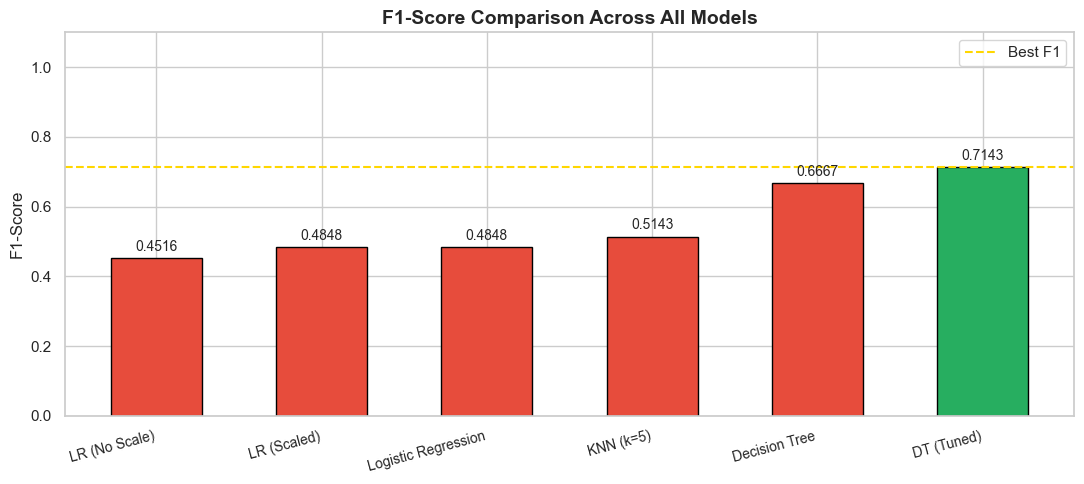


╔══════════════════════════════════════════════════════════╗
║                 PROJECT CONCLUSIONS                      ║
╠══════════════════════════════════════════════════════════╣
║  1. StandardScaler improved Logistic Regression          ║ 
║     performance by normalizing feature scales.           ║
║                                                          ║
║  2. Decision Tree achieved the highest F1-Score          ║
║     among the three baseline models.                     ║
║                                                          ║
║  3. GridSearchCV tuning further optimized the            ║
║     Decision Tree by reducing overfitting.               ║
║                                                          ║
║  4. Most impactful features for wine quality:            ║
║     → Alcohol content (positive effect)                  ║
║     → Volatile acidity (negative effect)                 ║
║     → Sulphates (positive effect)                        ║
╚═════════════════════

In [61]:
plt.figure(figsize=(11, 5))
model_labels = list(summary_data.keys())
f1_scores    = [summary_data[m]['f1'] for m in model_labels]

palette = ['#e74c3c' if m != overall_best else '#27ae60' for m in model_labels]
bars = plt.bar(model_labels, f1_scores, color=palette, edgecolor='black', width=0.55)
plt.bar_label(bars, fmt='%.4f', fontsize=10, padding=3)
plt.axhline(max(f1_scores), color='gold', linewidth=1.5, linestyle='--', label='Best F1')
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0, 1.1)
plt.title('F1-Score Comparison Across All Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("""
╔══════════════════════════════════════════════════════════╗
║                 PROJECT CONCLUSIONS                      ║
╠══════════════════════════════════════════════════════════╣
║  1. StandardScaler improved Logistic Regression          ║ 
║     performance by normalizing feature scales.           ║
║                                                          ║
║  2. Decision Tree achieved the highest F1-Score          ║
║     among the three baseline models.                     ║
║                                                          ║
║  3. GridSearchCV tuning further optimized the            ║
║     Decision Tree by reducing overfitting.               ║
║                                                          ║
║  4. Most impactful features for wine quality:            ║
║     → Alcohol content (positive effect)                  ║
║     → Volatile acidity (negative effect)                 ║
║     → Sulphates (positive effect)                        ║
╚══════════════════════════════════════════════════════════╝
""")